# Example climb: save the princess

**Goal**: maximize the probability of a cure while using the least total ingredients

## 1. Notebook setup

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

sys.path.append('..')

from hill_climber import HillClimber

np.random.seed(315)

## 2. Potion model

### 2.1. Data preparation

In [2]:
df = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit3/Cure_the_princess.csv')

train_df, test_df = train_test_split(df)
train_df.info()    

<class 'pandas.core.frame.DataFrame'>
Index: 1753 entries, 2137 to 611
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Phoenix Feather  1753 non-null   float64
 1   Unicorn Horn     1753 non-null   float64
 2   Dragon's Blood   1753 non-null   float64
 3   Mermaid Tears    1753 non-null   float64
 4   Fairy Dust       1753 non-null   float64
 5   Goblin Toes      1753 non-null   float64
 6   Witch's Brew     1753 non-null   float64
 7   Griffin Claw     1753 non-null   float64
 8   Troll Hair       1753 non-null   float64
 9   Kraken Ink       1753 non-null   float64
 10  Minotaur Horn    1753 non-null   float64
 11  Basilisk Scale   1753 non-null   float64
 12  Chimera Fang     1753 non-null   float64
 13  Cured            1753 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 205.4 KB


### 2.2. Model training

In [3]:
model = GradientBoostingClassifier()
_ = model.fit(train_df.drop(columns=['Cured']), train_df['Cured'])

### 2.3. Model evaluation

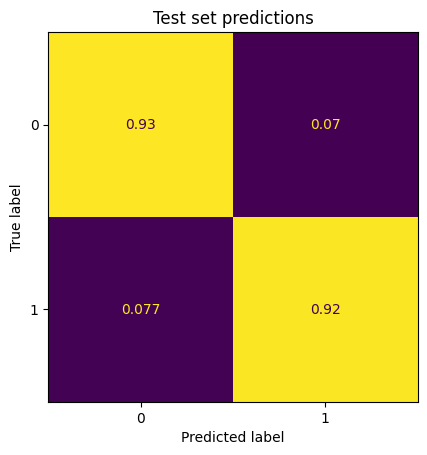

In [4]:
predictions = model.predict(test_df.drop(columns=['Cured']))

ConfusionMatrixDisplay.from_predictions(
    test_df['Cured'],
    predictions,
    normalize='true',
    colorbar=False
)

plt.title('Test set predictions')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

### 2.4. Retrain with complete dataset

In [5]:
_ = model.fit(df.drop(columns=['Cured']), df['Cured'])

## 3. Find best potion

### 3.1. Starting potion

In [6]:
# Get max ingredient values from the dataset
max_values = df.drop(columns='Cured').describe().loc['max']
max_values

Phoenix Feather    42.1
Unicorn Horn       34.1
Dragon's Blood     40.8
Mermaid Tears      35.8
Fairy Dust         40.4
Goblin Toes        37.8
Witch's Brew       37.3
Griffin Claw       39.4
Troll Hair         44.8
Kraken Ink         39.5
Minotaur Horn      33.7
Basilisk Scale     42.0
Chimera Fang       37.8
Name: max, dtype: float64

In [7]:
# Create a random starting potion where each ingredient is between 0 and its max value
starting_potion = {}

for feature, value in max_values.items():
    starting_potion[feature] = [np.random.uniform(0, max_values.loc[feature])]

starting_potion_df = pd.DataFrame(starting_potion)
starting_potion_df

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,32.316773,2.974719,25.788348,19.17993,33.715806,34.298547,23.000576,35.818569,21.774855,12.140236,27.197326,40.383144,27.155311


### 3.2. Hill climbing objective function

In [8]:
# Get total max value sum for all ingredients. Will be used to calculate a
# penalty term based on total ingredient values in the potion.
total_max_value = max_values.sum()
print(f'Combined max value for all ingredients: {total_max_value}')

Combined max value for all ingredients: 505.5


In [9]:
# Get feature names
features = max_values.index.tolist()
print(f'Features: {features}')

Features: ['Phoenix Feather', 'Unicorn Horn', "Dragon's Blood", 'Mermaid Tears', 'Fairy Dust', 'Goblin Toes', "Witch's Brew", 'Griffin Claw', 'Troll Hair', 'Kraken Ink', 'Minotaur Horn', 'Basilisk Scale', 'Chimera Fang']


In [10]:
def score_potion(*args):

    global features
    global model
    global total_max_value

    # Stack columns horizontally to create DataFrame
    potion_df = pd.DataFrame(
        np.column_stack(args),
        columns=features
    )

    # Predict cure probability
    cure_probability = model.predict_proba(potion_df)[0, 1]

    # Calculate total ingredient penalty
    ingredient_sum = potion_df.sum(axis=1).values[0]
    penalty = ingredient_sum / total_max_value
    
    # Return metrics dict and objective value
    metrics = {
        'Cure probability': cure_probability,
        'Ingredient penalty': penalty
    }
    
    objective = cure_probability - penalty

    return metrics, objective

### 3.3. Hill climb optimization

In [11]:
climber = HillClimber(
    data=starting_potion_df,
    objective_func=score_potion,
    initial_step_spread=0.25,
    final_step_spread=0.0025,
    T_min=0.0001,
    T_max=0.01,
    cooling_rate=1e-10,
    exchange_interval=100,
    max_time=3,
    n_replicas=10,
    db_path='../data/princess.db'
)

# Create bounds tuple from 0 to max_values
lower_bounds = np.zeros(len(max_values))
upper_bounds = max_values.values

# Override the bounds that were auto-calculated from the single-row data
climber.bounds = (lower_bounds, upper_bounds)

# Run optimization (step_spread_absolute will be calculated using current bounds)
best_data = climber.climb()

HillClimber Configuration

Data shape:           (1, 13)
Optimization mode:    maximize
Max runtime:          3 minutes

Temperature settings:
  T_min:              0.0001
  T_max:              0.01
  Cooling rate:       1e-10
  Temperature scheme: geometric

Replica exchange:
  Number of replicas: 10
  Exchange interval:  100 steps
  Exchange strategy:  even_odd
  Worker processes:   10

Perturbation settings:
  Initial step spread: 0.25 (fraction of range)
  Final step spread:   0.0025 (fraction at end of run)
  Perturb fraction:    0.001

Database settings:
  Enabled:            True
  Path:               ../data/princess.db
  Step interval:      10



### 4. Results

In [12]:
results_df = pd.concat(climber.get_replicas(), axis=0)
results_df.head(10)

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,0.164238,0.148825,0.018476,0.022739,0.233722,0.024715,25.574188,0.212209,0.018145,0.026022,0.265091,0.050635,0.003418
0,0.070181,0.048351,0.079267,0.017295,0.134722,0.573904,25.693822,0.037696,0.128744,0.106866,0.335645,0.739715,0.296974
0,0.119228,0.016446,0.054290,0.087830,0.087588,0.195445,13.803830,0.114721,11.940255,0.061382,0.127499,0.011053,0.055487
0,0.011379,0.240042,0.648105,0.076593,0.186756,0.152426,25.905972,0.064701,0.450048,0.015056,0.113434,0.016230,0.120571
0,0.019248,0.027822,0.050447,0.029125,0.155173,0.216575,0.090592,0.011469,25.451192,0.524121,0.009043,0.012134,0.097851
0,0.023697,0.068746,0.159399,0.176107,0.075290,0.112668,13.786543,0.274684,11.999080,0.135503,0.391086,0.003010,0.271288
0,0.045521,0.036585,0.074201,0.030894,0.066877,0.149192,13.987923,0.014373,11.914109,0.219920,0.091783,0.248186,0.005300
0,0.317690,0.338730,0.264125,0.004925,0.059954,1.086603,25.723373,0.074593,0.134664,0.288585,0.204490,0.047049,0.129981
0,0.016393,0.105273,0.055992,0.091640,0.107198,0.222556,25.861828,0.177093,0.104994,0.032454,0.033182,0.028548,0.009975
0,0.042081,0.085507,0.097376,0.074734,0.052662,0.393120,0.143371,0.305234,20.237307,0.033296,0.069770,0.306326,0.117044


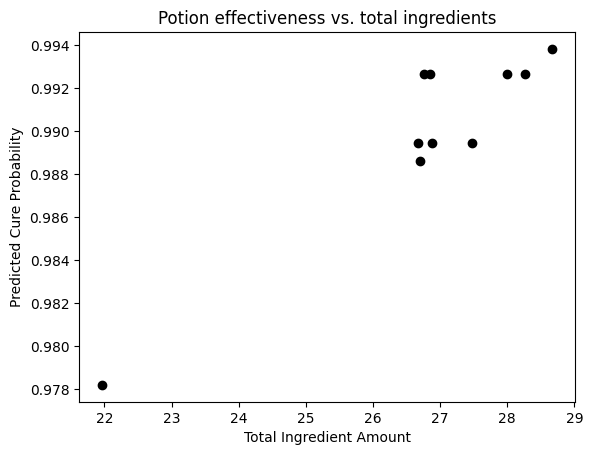

Best cure probability: 0.9938
Lowest ingredient sum: 21.96
Best objective (cure - penalty): 0.9397


In [13]:
predictions = model.predict_proba(results_df)[:, 1]
ingredient_sums = results_df.sum(axis=1)

# Create scatter plot
plt.title('Potion effectiveness vs. total ingredients')
plt.scatter(ingredient_sums, predictions, c='black')
plt.xlabel('Total Ingredient Amount')
plt.ylabel('Predicted Cure Probability')
plt.show()

# Print summary statistics
print(f'Best cure probability: {predictions.max():.4f}')
print(f'Lowest ingredient sum: {ingredient_sums.min():.2f}')
print(f'Best objective (cure - penalty): {(predictions - ingredient_sums/total_max_value).max():.4f}')

### 4.1. Verify per-feature step sizes

The hill climber now uses **per-feature step sizes** based on each ingredient's range, rather than averaging across all features.

In [14]:
# Check the ingredient ranges
ingredient_ranges = max_values.values
print("Ingredient ranges:")

for feature, range_val in zip(features, ingredient_ranges):
    print(f"  {feature}: {range_val:.2f}")

print(f"\nInitial step spread parameter: {climber.initial_step_spread}")
print(f"\nPer-feature step sizes (standard deviation of perturbations):")

for feature, step_size in zip(features, climber.step_spread_absolute):
    print(f"  {feature}: {step_size:.4f}")

Ingredient ranges:
  Phoenix Feather: 42.10
  Unicorn Horn: 34.10
  Dragon's Blood: 40.80
  Mermaid Tears: 35.80
  Fairy Dust: 40.40
  Goblin Toes: 37.80
  Witch's Brew: 37.30
  Griffin Claw: 39.40
  Troll Hair: 44.80
  Kraken Ink: 39.50
  Minotaur Horn: 33.70
  Basilisk Scale: 42.00
  Chimera Fang: 37.80

Initial step spread parameter: 0.25

Per-feature step sizes (standard deviation of perturbations):
  Phoenix Feather: 10.5250
  Unicorn Horn: 8.5250
  Dragon's Blood: 10.2000
  Mermaid Tears: 8.9500
  Fairy Dust: 10.1000
  Goblin Toes: 9.4500
  Witch's Brew: 9.3250
  Griffin Claw: 9.8500
  Troll Hair: 11.2000
  Kraken Ink: 9.8750
  Minotaur Horn: 8.4250
  Basilisk Scale: 10.5000
  Chimera Fang: 9.4500
